# Chapter 26 Python Lab  
## Multivariable Calculus for Applied Mathematics

This lab accompanies **Chapter 26: Multivariable Calculus for Applied Mathematics**.

Applied mathematics uses multivariable calculus to translate real systems into computable models.

The central objects are familiar:

- scalar fields $u(x,y)$ for temperature, density, concentration, pressure, and energy;
- vector fields $\mathbf F(x,y)$ for velocity, force, flux, and gradient flow;
- gradients $\nabla u$ for direction of steepest change;
- divergence $\nabla\cdot\mathbf F$ for local source/sink balance;
- curl for rotation;
- Laplacians $\Delta u=\nabla\cdot\nabla u$ for diffusion and smoothing;
- Jacobians for linearization of nonlinear systems;
- Hessians for curvature and stability;
- integrals for total mass, energy, and flux.

This lab uses `numpy` and `matplotlib` to explore core applied-mathematics models:

- phase portraits and linear dynamical systems;
- nonlinear population dynamics;
- gradient flows and energy decay;
- Hamiltonian systems and energy conservation;
- numerical gradients, divergence, and Laplacians;
- the heat equation and diffusion;
- Poisson equations and steady states;
- variational energy minimization;
- advection-diffusion transport;
- conservation and flux balance;
- and a mini-project on pollutant diffusion with wind.

Only `numpy` and `matplotlib` are required.

## Learning goals

By the end of this lab, you should be able to:

1. simulate systems of differential equations using vector fields;
2. interpret linear systems using eigenvalues and phase portraits;
3. use Jacobians to linearize nonlinear dynamical systems;
4. recognize gradient flows and verify energy decreases along them;
5. recognize Hamiltonian systems and check approximate energy conservation;
6. compute numerical gradients, divergence, and Laplacians on grids;
7. simulate heat diffusion using finite differences;
8. solve simple steady-state equations by iteration;
9. connect flux, divergence, and conservation;
10. build a small applied model involving diffusion, wind, and sources.

## Source note

This notebook was generated from the uploaded Chapter 26 QMD file.  
The extracted early headings from the source file include:

- Multivariable Calculus for Applied Mathematics
- Learning goals
- 26.1 The applied mathematics pipeline
- 26.2 Scalar fields, vector fields, and operators
- Interpretation of the operators
- Example 26.1: gradient, divergence, curl, and Laplacian
- 26.3 Balance laws and conservation
- Conservation law template
- Example 26.2: source, sink, and incompressible fields
- 26.4 Diffusion and the heat equation
- Why the Laplacian appears
- Spatial grid
- Stable explicit time step for u_t = kappa u_xx
- 26.5 The Laplacian as local averaging
- 26.6 Advection and transport
- Example 26.3: rotation transports density

## 0. Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
norm = np.linalg.norm

def make_grid(xmin=-3, xmax=3, ymin=-3, ymax=3, n=250):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y

def make_midpoint_grid(xmin, xmax, ymin, ymax, nx=300, ny=300):
    dx = (xmax-xmin)/nx
    dy = (ymax-ymin)/ny
    x = xmin + (np.arange(nx)+0.5)*dx
    y = ymin + (np.arange(ny)+0.5)*dy
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y, dx, dy

def safe_eval_2d(f, X, Y):
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        Z = f(X, Y)
    return np.asarray(Z, dtype=float)

def vector_magnitude(U, V):
    return np.sqrt(U**2 + V**2)

def unit_vector_field(U, V, eps=1e-12):
    M = vector_magnitude(U, V)
    return U/(M+eps), V/(M+eps), M

def plot_vector_field(F, xmin=-3, xmax=3, ymin=-3, ymax=3, n=25,
                      normalize=True, title="Vector field"):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    U, V = F(X, Y)
    M = vector_magnitude(U, V)
    if normalize:
        Uplot, Vplot, _ = unit_vector_field(U, V)
    else:
        Uplot, Vplot = U, V
    plt.figure(figsize=(7, 6))
    plt.quiver(X, Y, Uplot, Vplot, M)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True, alpha=0.25)
    plt.show()
    return X, Y, U, V, M

def euler_solve(F, x0, t0=0.0, t1=10.0, dt=0.01):
    steps = int(np.ceil((t1-t0)/dt))
    t = t0 + np.arange(steps+1)*dt
    X = np.zeros((steps+1, len(x0)), dtype=float)
    X[0] = np.asarray(x0, dtype=float)
    for k in range(steps):
        X[k+1] = X[k] + dt*np.asarray(F(t[k], X[k]), dtype=float)
    return t, X

def rk4_solve(F, x0, t0=0.0, t1=10.0, dt=0.01):
    steps = int(np.ceil((t1-t0)/dt))
    t = t0 + np.arange(steps+1)*dt
    X = np.zeros((steps+1, len(x0)), dtype=float)
    X[0] = np.asarray(x0, dtype=float)
    for k in range(steps):
        h = dt
        tk = t[k]
        xk = X[k]
        k1 = np.asarray(F(tk, xk), dtype=float)
        k2 = np.asarray(F(tk+h/2, xk+h*k1/2), dtype=float)
        k3 = np.asarray(F(tk+h/2, xk+h*k2/2), dtype=float)
        k4 = np.asarray(F(tk+h, xk+h*k3), dtype=float)
        X[k+1] = xk + h*(k1+2*k2+2*k3+k4)/6
    return t, X

def plot_phase_paths(F_autonomous, starts, xmin=-3, xmax=3, ymin=-3, ymax=3,
                     t1=8.0, dt=0.02, title="Phase portrait"):
    def field_grid(X, Y):
        U = np.zeros_like(X, dtype=float)
        V = np.zeros_like(Y, dtype=float)
        for index in np.ndindex(X.shape):
            val = F_autonomous(np.array([X[index], Y[index]], dtype=float))
            U[index] = val[0]
            V[index] = val[1]
        return U, V
    x = np.linspace(xmin, xmax, 25)
    y = np.linspace(ymin, ymax, 25)
    X, Y = np.meshgrid(x, y)
    U, V = field_grid(X, Y)
    Uq, Vq, _ = unit_vector_field(U, V)
    plt.figure(figsize=(7, 6))
    plt.quiver(X, Y, Uq, Vq, alpha=0.45)
    for s in starts:
        F_time = lambda t, z: F_autonomous(z)
        t, path = rk4_solve(F_time, s, 0, t1, dt)
        plt.plot(path[:,0], path[:,1], linewidth=2)
        plt.scatter([path[0,0]], [path[0,1]], s=45)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.grid(True, alpha=0.25)
    plt.show()

def finite_gradient_scalar_grid(U, dx, dy):
    Uy, Ux = np.gradient(U, dy, dx, edge_order=2)
    return Ux, Uy

def finite_divergence_grid(P, Q, dx, dy):
    Qy, _ = np.gradient(Q, dy, dx, edge_order=2)
    _, Px = np.gradient(P, dy, dx, edge_order=2)
    return Px + Qy

def finite_laplacian_grid(U, dx, dy):
    Uy, Ux = np.gradient(U, dy, dx, edge_order=2)
    Uyy, _ = np.gradient(Uy, dy, dx, edge_order=2)
    _, Uxx = np.gradient(Ux, dy, dx, edge_order=2)
    return Uxx + Uyy

def integrate_grid(U, dx, dy):
    return float(np.sum(U)*dx*dy)

def heat_step_neumann(U, alpha, dx, dy, dt):
    # Reflecting boundary via edge padding.
    Up = np.pad(U, pad_width=1, mode="edge")
    lap = (
        (Up[1:-1,2:] - 2*Up[1:-1,1:-1] + Up[1:-1,:-2])/dx**2
        + (Up[2:,1:-1] - 2*Up[1:-1,1:-1] + Up[:-2,1:-1])/dy**2
    )
    return U + alpha*dt*lap

def heat_step_dirichlet_zero(U, alpha, dx, dy, dt):
    Un = U.copy()
    lap = (
        (U[1:-1,2:] - 2*U[1:-1,1:-1] + U[1:-1,:-2])/dx**2
        + (U[2:,1:-1] - 2*U[1:-1,1:-1] + U[:-2,1:-1])/dy**2
    )
    Un[1:-1,1:-1] = U[1:-1,1:-1] + alpha*dt*lap
    Un[0,:] = 0; Un[-1,:] = 0; Un[:,0] = 0; Un[:,-1] = 0
    return Un

def upwind_advection_diffusion_step(U, vx, vy, D, dx, dy, dt, source=None):
    # Neumann-like edge values for diffusion and upwind derivatives.
    Up = np.pad(U, pad_width=1, mode="edge")
    lap = (
        (Up[1:-1,2:] - 2*Up[1:-1,1:-1] + Up[1:-1,:-2])/dx**2
        + (Up[2:,1:-1] - 2*Up[1:-1,1:-1] + Up[:-2,1:-1])/dy**2
    )
    if vx >= 0:
        ux = (Up[1:-1,1:-1] - Up[1:-1,:-2])/dx
    else:
        ux = (Up[1:-1,2:] - Up[1:-1,1:-1])/dx
    if vy >= 0:
        uy = (Up[1:-1,1:-1] - Up[:-2,1:-1])/dy
    else:
        uy = (Up[2:,1:-1] - Up[1:-1,1:-1])/dy
    S = 0 if source is None else source
    return U + dt*(D*lap - vx*ux - vy*uy + S)

def finite_jacobian(F, p, h=1e-5):
    p = np.asarray(p, dtype=float)
    f0 = np.asarray(F(p), dtype=float)
    J = np.zeros((len(f0), len(p)))
    for j in range(len(p)):
        step = np.zeros_like(p)
        step[j] = h
        J[:,j] = (np.asarray(F(p+step)) - np.asarray(F(p-step)))/(2*h)
    return J

def contour_scalar_field(f, xmin=-3, xmax=3, ymin=-3, ymax=3, n=300, levels=24, title="Contours"):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n)
    Z = safe_eval_2d(f, X, Y)
    plt.figure(figsize=(7, 6))
    cs = plt.contour(X, Y, Z, levels=levels)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True, alpha=0.25)
    plt.show()
    return X, Y, Z

print("Setup complete.")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-j1ullyph because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup complete.


---

# Part I. Linear dynamical systems and phase portraits

A linear autonomous system has the form

$$
\frac{d\mathbf x}{dt}=A\mathbf x.
$$

The matrix $A$ determines the geometry:

- eigenvalues with negative real part give attraction;
- eigenvalues with positive real part give repulsion;
- mixed signs give a saddle;
- complex eigenvalues give spirals or rotations.

This is multivariable calculus because the vector field $\mathbf F(\mathbf x)=A\mathbf x$ is the local velocity field.

## 1. A stable spiral

Consider

$$
A=
\begin{bmatrix}
-0.2&-1\\
1&-0.2
\end{bmatrix}.
$$

The eigenvalues are $-0.2\pm i$, so trajectories spiral inward.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Eigenvalues: [-0.2+1.j -0.2-1.j]


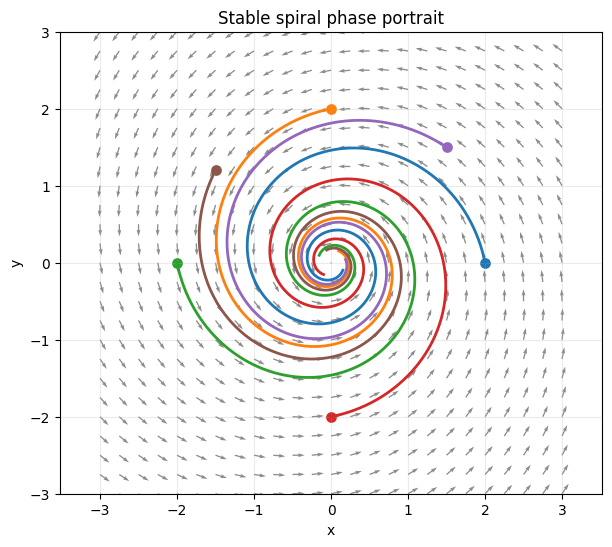

In [2]:
A_spiral = np.array([[-0.2, -1.0],
                     [ 1.0, -0.2]])

eig_spiral = np.linalg.eigvals(A_spiral)
print("Eigenvalues:", eig_spiral)

def F_spiral_state(z):
    return A_spiral @ z

starts = [
    [2, 0], [0, 2], [-2, 0], [0, -2],
    [1.5, 1.5], [-1.5, 1.2]
]

plot_phase_paths(
    F_spiral_state,
    starts,
    xmin=-3, xmax=3,
    ymin=-3, ymax=3,
    t1=12,
    dt=0.02,
    title="Stable spiral phase portrait"
)

## 2. A saddle system

Now use

$$
A=
\begin{bmatrix}
1&0\\
0&-2
\end{bmatrix}.
$$

The $x$ direction is unstable and the $y$ direction is stable.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Eigenvalues: [ 1. -2.]


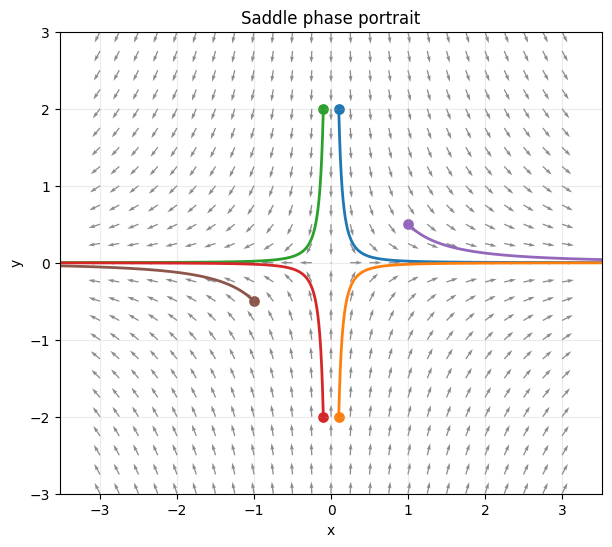

In [3]:
A_saddle = np.array([[1.0, 0.0],
                     [0.0, -2.0]])

print("Eigenvalues:", np.linalg.eigvals(A_saddle))

def F_saddle_state(z):
    return A_saddle @ z

starts = [
    [0.1, 2], [0.1, -2], [-0.1, 2], [-0.1, -2],
    [1.0, 0.5], [-1.0, -0.5]
]

plot_phase_paths(
    F_saddle_state,
    starts,
    xmin=-3, xmax=3,
    ymin=-3, ymax=3,
    t1=4,
    dt=0.01,
    title="Saddle phase portrait"
)

## 3. Matrix exponential viewpoint

The exact solution of

$$
\mathbf x'=A\mathbf x
$$

is

$$
\mathbf x(t)=e^{tA}\mathbf x(0).
$$

Without using SciPy, we can compare the numerical solution with a truncated matrix exponential series.

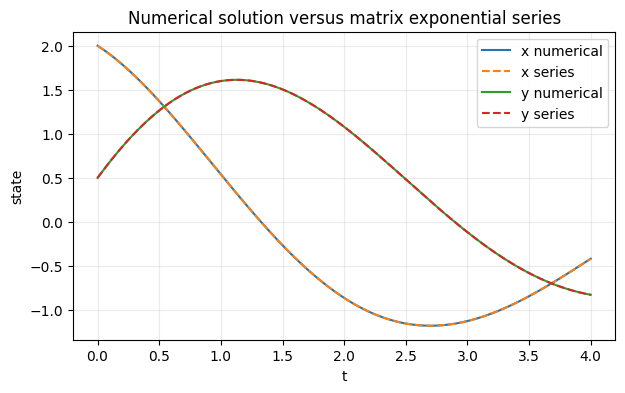

Maximum difference over trajectory: 5.4674775863104565e-09


In [4]:
def matrix_exp_series(A, t, terms=40):
    n = A.shape[0]
    result = np.eye(n)
    term = np.eye(n)
    for k in range(1, terms):
        term = term @ (t*A)/k
        result = result + term
    return result

x0 = np.array([2.0, 0.5])
t, X_num = rk4_solve(lambda t, z: A_spiral @ z, x0, 0, 4, 0.02)

X_exact = np.array([matrix_exp_series(A_spiral, tk) @ x0 for tk in t])

error = np.max(np.linalg.norm(X_num - X_exact, axis=1))

plt.figure(figsize=(7, 4))
plt.plot(t, X_num[:,0], label="x numerical")
plt.plot(t, X_exact[:,0], linestyle="--", label="x series")
plt.plot(t, X_num[:,1], label="y numerical")
plt.plot(t, X_exact[:,1], linestyle="--", label="y series")
plt.xlabel("t")
plt.ylabel("state")
plt.title("Numerical solution versus matrix exponential series")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print("Maximum difference over trajectory:", error)

---

# Part II. Nonlinear systems and linearization

A nonlinear autonomous system has the form

$$
\mathbf x'=\mathbf F(\mathbf x).
$$

Near an equilibrium point $\mathbf x_*$ satisfying $\mathbf F(\mathbf x_*)=0$, the linearization is

$$
\mathbf h'=J_{\mathbf F}(\mathbf x_*)\mathbf h,
$$

where $J_{\mathbf F}$ is the Jacobian matrix.

## 4. Predator-prey dynamics

The Lotka--Volterra model is

$$
x'=ax-bxy,
$$

$$
y'=-cy+dxy,
$$

where $x$ is prey and $y$ is predator.

Use parameters

$$
a=1.2,\qquad b=0.6,\qquad c=0.8,\qquad d=0.3.
$$

The nonzero equilibrium is

$$
(x_*,y_*)=\left(\frac c d,\frac a b\right).
$$

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Nonzero equilibrium: [2.666667 2.      ]
Jacobian at equilibrium:
[[ 0.  -1.6]
 [ 0.6  0. ]]
Eigenvalues: [0.+0.979796j 0.-0.979796j]


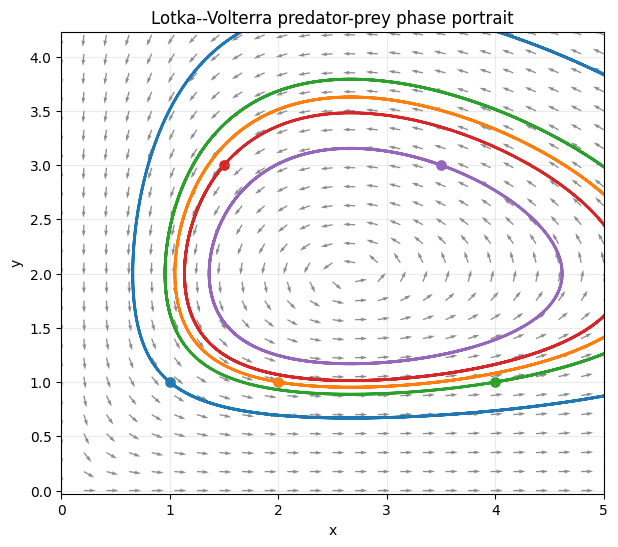

In [5]:
a, b, c, d = 1.2, 0.6, 0.8, 0.3

def F_lotka_state(z):
    x, y = z
    return np.array([a*x - b*x*y, -c*y + d*x*y])

equilibrium_lv = np.array([c/d, a/b])
J_lv = finite_jacobian(F_lotka_state, equilibrium_lv)

print("Nonzero equilibrium:", equilibrium_lv)
print("Jacobian at equilibrium:")
print(J_lv)
print("Eigenvalues:", np.linalg.eigvals(J_lv))

starts = [
    [1.0, 1.0], [2.0, 1.0], [4.0, 1.0],
    [1.5, 3.0], [3.5, 3.0]
]

plot_phase_paths(
    F_lotka_state,
    starts,
    xmin=0, xmax=5,
    ymin=0, ymax=4.2,
    t1=18,
    dt=0.02,
    title="Lotka--Volterra predator-prey phase portrait"
)

## 5. Time series for predator-prey dynamics

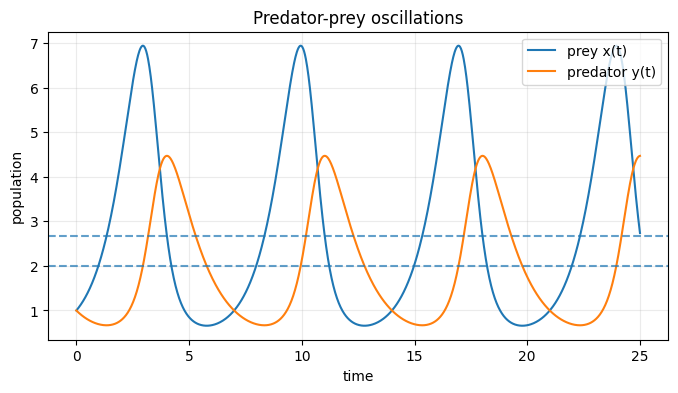

In [6]:
t, sol = rk4_solve(lambda t, z: F_lotka_state(z), np.array([1.0, 1.0]), 0, 25, 0.02)

plt.figure(figsize=(8, 4))
plt.plot(t, sol[:,0], label="prey x(t)")
plt.plot(t, sol[:,1], label="predator y(t)")
plt.axhline(equilibrium_lv[0], linestyle="--", alpha=0.7)
plt.axhline(equilibrium_lv[1], linestyle="--", alpha=0.7)
plt.xlabel("time")
plt.ylabel("population")
plt.title("Predator-prey oscillations")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 6. Linearization versus nonlinear dynamics near equilibrium

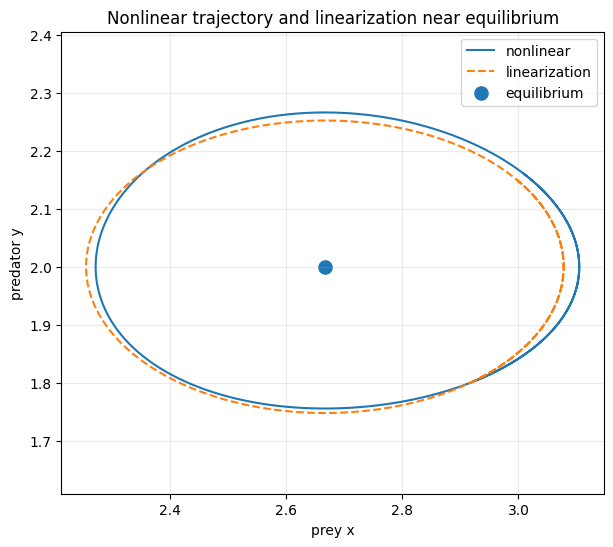

Initial point: [2.916667 1.8     ]
Equilibrium: [2.666667 2.      ]


In [7]:
perturbation = np.array([0.25, -0.20])
z0 = equilibrium_lv + perturbation

t, nonlinear = rk4_solve(lambda t, z: F_lotka_state(z), z0, 0, 8, 0.01)
linear_pert = np.array([matrix_exp_series(J_lv, tk, terms=40) @ perturbation for tk in t])
linear_approx = equilibrium_lv + linear_pert

plt.figure(figsize=(7, 6))
plt.plot(nonlinear[:,0], nonlinear[:,1], label="nonlinear")
plt.plot(linear_approx[:,0], linear_approx[:,1], linestyle="--", label="linearization")
plt.scatter([equilibrium_lv[0]], [equilibrium_lv[1]], s=90, label="equilibrium")
plt.xlabel("prey x")
plt.ylabel("predator y")
plt.title("Nonlinear trajectory and linearization near equilibrium")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print("Initial point:", z0)
print("Equilibrium:", equilibrium_lv)

---

# Part III. Gradient flows and energy decay

A gradient flow has the form

$$
\mathbf x'=-\nabla V(\mathbf x),
$$

where $V$ is an energy or potential.

Along a solution,

$$
\frac{d}{dt}V(\mathbf x(t))
=
\nabla V(\mathbf x(t))\cdot \mathbf x'(t)
=
-|\nabla V(\mathbf x(t))|^2\leq0.
$$

Thus energy decreases along trajectories.

## 7. A double-well potential

Let

$$
V(x,y)=\frac14(x^2-1)^2+\frac12y^2+0.15xy.
$$

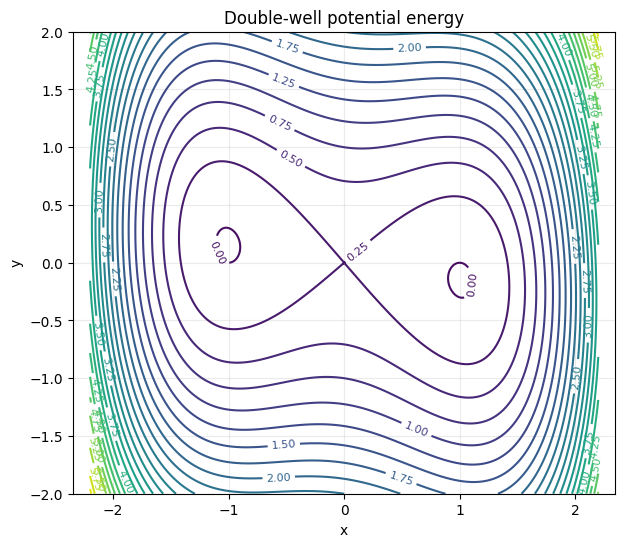

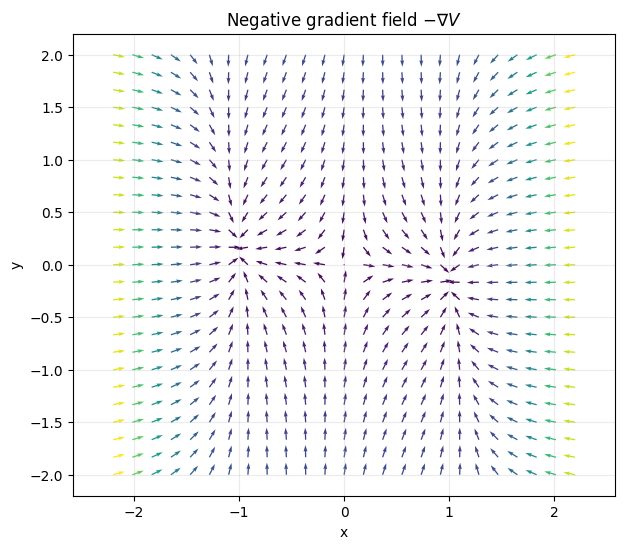

(array([[-2.2     , -2.016667, -1.833333, -1.65    , -1.466667, -1.283333,
         -1.1     , -0.916667, -0.733333, -0.55    , -0.366667, -0.183333,
          0.      ,  0.183333,  0.366667,  0.55    ,  0.733333,  0.916667,
          1.1     ,  1.283333,  1.466667,  1.65    ,  1.833333,  2.016667,
          2.2     ],
        [-2.2     , -2.016667, -1.833333, -1.65    , -1.466667, -1.283333,
         -1.1     , -0.916667, -0.733333, -0.55    , -0.366667, -0.183333,
          0.      ,  0.183333,  0.366667,  0.55    ,  0.733333,  0.916667,
          1.1     ,  1.283333,  1.466667,  1.65    ,  1.833333,  2.016667,
          2.2     ],
        [-2.2     , -2.016667, -1.833333, -1.65    , -1.466667, -1.283333,
         -1.1     , -0.916667, -0.733333, -0.55    , -0.366667, -0.183333,
          0.      ,  0.183333,  0.366667,  0.55    ,  0.733333,  0.916667,
          1.1     ,  1.283333,  1.466667,  1.65    ,  1.833333,  2.016667,
          2.2     ],
        [-2.2     , -2.016667, -1.833

In [8]:
def V_double(X, Y):
    return 0.25*(X**2 - 1)**2 + 0.5*Y**2 + 0.15*X*Y

def grad_V_double_state(z):
    x, y = z
    Vx = x*(x**2 - 1) + 0.15*y
    Vy = y + 0.15*x
    return np.array([Vx, Vy])

def F_gradient_flow(z):
    return -grad_V_double_state(z)

def F_gradient_grid(X, Y):
    U = -(X*(X**2 - 1) + 0.15*Y)
    V = -(Y + 0.15*X)
    return U, V

contour_scalar_field(
    V_double,
    xmin=-2.2, xmax=2.2,
    ymin=-2, ymax=2,
    levels=30,
    title="Double-well potential energy"
)

plot_vector_field(
    F_gradient_grid,
    xmin=-2.2, xmax=2.2,
    ymin=-2, ymax=2,
    n=25,
    normalize=True,
    title=r"Negative gradient field $-\nabla V$"
)

## 8. Energy decreases along gradient flow

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


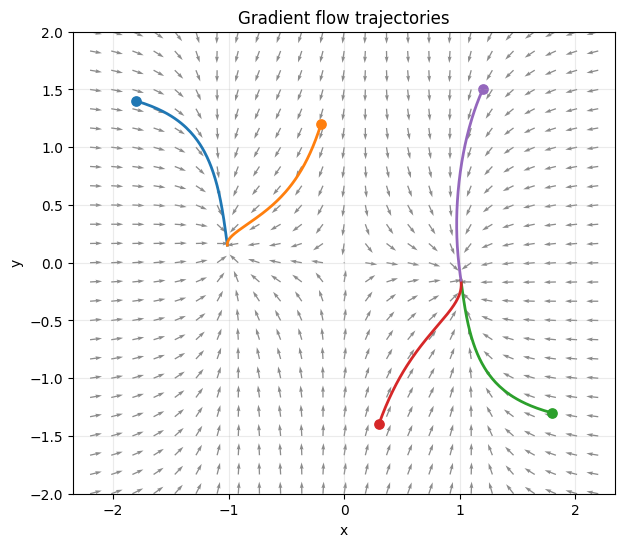

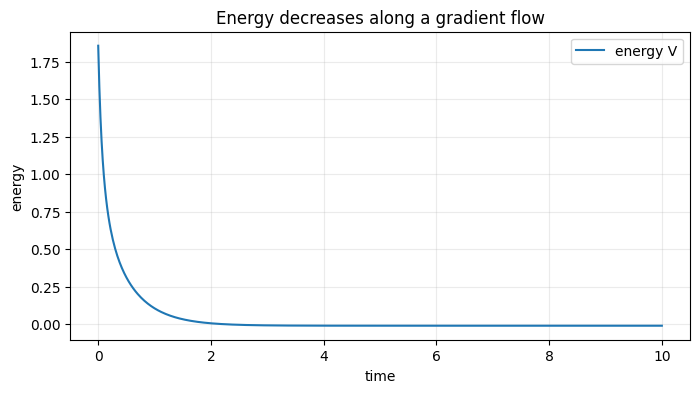

Initial energy: 1.8563999999999998
Final energy: -0.011376559974726412
Minimum numerical energy difference step: -0.27332119578484093
Mean |grad V|^2 along path: 0.20310185109757883


In [9]:
starts = [[-1.8, 1.4], [-0.2, 1.2], [1.8, -1.3], [0.3, -1.4], [1.2, 1.5]]

plot_phase_paths(
    F_gradient_flow,
    starts,
    xmin=-2.2, xmax=2.2,
    ymin=-2, ymax=2,
    t1=8,
    dt=0.02,
    title="Gradient flow trajectories"
)

t, path = rk4_solve(lambda t, z: F_gradient_flow(z), np.array([-1.8, 1.4]), 0, 10, 0.02)
energy = V_double(path[:,0], path[:,1])
grad_norm2 = np.array([norm(grad_V_double_state(p))**2 for p in path])

plt.figure(figsize=(8, 4))
plt.plot(t, energy, label="energy V")
plt.xlabel("time")
plt.ylabel("energy")
plt.title("Energy decreases along a gradient flow")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

print("Initial energy:", energy[0])
print("Final energy:", energy[-1])
print("Minimum numerical energy difference step:", np.min(np.diff(energy)))
print("Mean |grad V|^2 along path:", np.mean(grad_norm2))

---

# Part IV. Hamiltonian systems and energy conservation

A Hamiltonian system in two variables has the form

$$
x'=H_y,\qquad y'=-H_x.
$$

For such systems,

$$
\frac{d}{dt}H(x(t),y(t))
=
H_xx'+H_yy'
=
H_xH_y-H_yH_x=0.
$$

Hamiltonian systems move along level curves of $H$.

## 9. A nonlinear oscillator

Let

$$
H(x,y)=\frac12y^2+\frac14x^4-\frac12x^2.
$$

Then

$$
x'=y,\qquad y'=-(x^3-x)=x-x^3.
$$

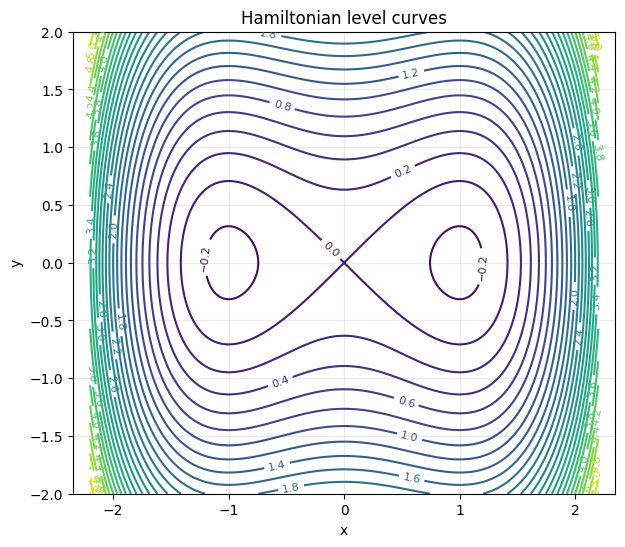

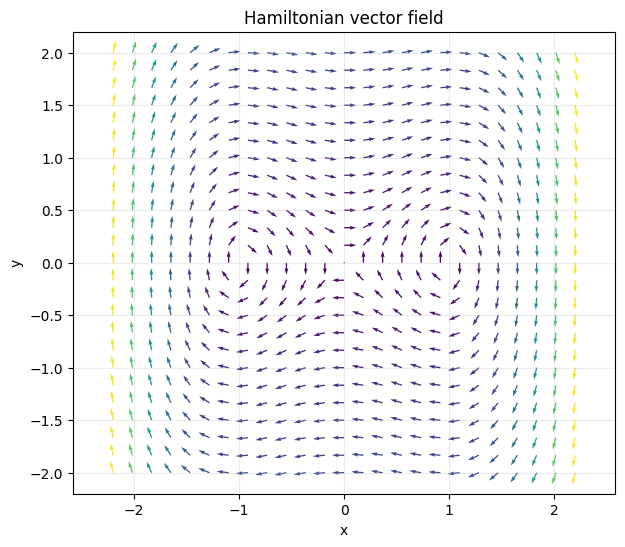

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


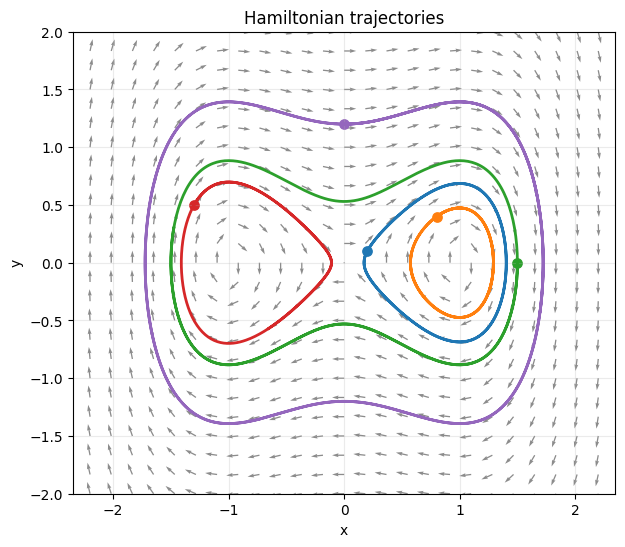

In [10]:
def H_osc(X, Y):
    return 0.5*Y**2 + 0.25*X**4 - 0.5*X**2

def F_hamiltonian_state(z):
    x, y = z
    return np.array([y, x - x**3])

def F_hamiltonian_grid(X, Y):
    return Y, X - X**3

contour_scalar_field(
    H_osc,
    xmin=-2.2, xmax=2.2,
    ymin=-2, ymax=2,
    levels=32,
    title="Hamiltonian level curves"
)

plot_vector_field(
    F_hamiltonian_grid,
    xmin=-2.2, xmax=2.2,
    ymin=-2, ymax=2,
    n=25,
    normalize=True,
    title="Hamiltonian vector field"
)

starts = [[0.2, 0.1], [0.8, 0.4], [1.5, 0.0], [-1.3, 0.5], [0.0, 1.2]]
plot_phase_paths(
    F_hamiltonian_state,
    starts,
    xmin=-2.2, xmax=2.2,
    ymin=-2, ymax=2,
    t1=14,
    dt=0.02,
    title="Hamiltonian trajectories"
)

## 10. Energy conservation check

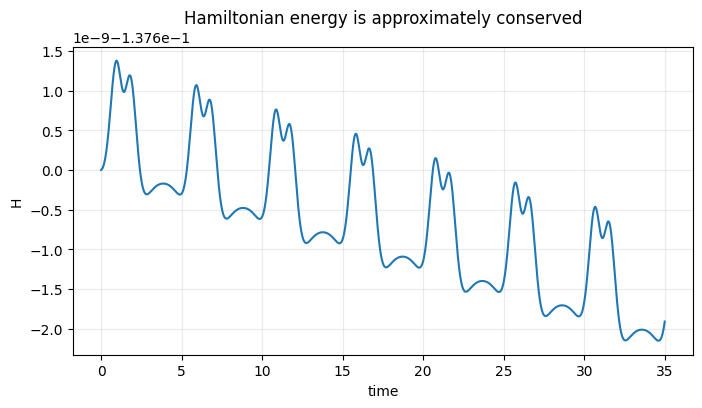

Initial H: -0.13760000000000003
Final H: -0.13760000190934346
Maximum energy drift: 2.150508937592832e-09


In [11]:
t, path = rk4_solve(lambda t, z: F_hamiltonian_state(z), np.array([0.8, 0.4]), 0, 35, 0.02)
energy_H = H_osc(path[:,0], path[:,1])

plt.figure(figsize=(8, 4))
plt.plot(t, energy_H)
plt.xlabel("time")
plt.ylabel("H")
plt.title("Hamiltonian energy is approximately conserved")
plt.grid(True, alpha=0.25)
plt.show()

print("Initial H:", energy_H[0])
print("Final H:", energy_H[-1])
print("Maximum energy drift:", np.max(np.abs(energy_H - energy_H[0])))

---

# Part V. Numerical differential operators on grids

Many applied models use fields defined on grids.  
Finite differences approximate multivariable calculus operators.

For a scalar field $u(x,y)$:

$$
\nabla u=\langle u_x,u_y\rangle.
$$

The Laplacian is

$$
\Delta u=u_{xx}+u_{yy}.
$$

For a vector field $\mathbf F=\langle P,Q\rangle$:

$$
\nabla\cdot\mathbf F=P_x+Q_y.
$$

## 11. Gradient, divergence, and Laplacian of a Gaussian hill

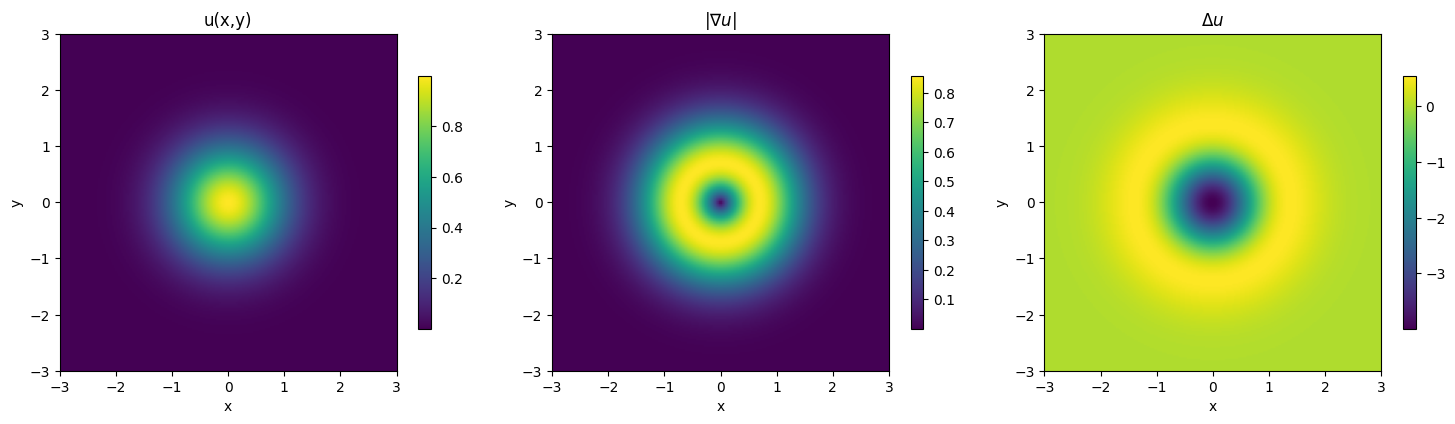

Max |Delta u - div(grad u)|: 0.0


In [12]:
x, y, X, Y = make_grid(-3, 3, -3, 3, n=220)
dx = x[1] - x[0]
dy = y[1] - y[0]

U = np.exp(-(X**2 + Y**2))
Ux, Uy = finite_gradient_scalar_grid(U, dx, dy)
LapU = finite_laplacian_grid(U, dx, dy)
DivGradU = finite_divergence_grid(Ux, Uy, dx, dy)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(
    axes,
    [U, np.sqrt(Ux**2+Uy**2), LapU],
    ["u(x,y)", r"$|\nabla u|$", r"$\Delta u$"]
):
    im = ax.imshow(data, extent=[-3,3,-3,3], origin="lower", aspect="equal")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax, shrink=0.75)
plt.tight_layout()
plt.show()

print("Max |Delta u - div(grad u)|:", np.max(np.abs(LapU - DivGradU)))

## 12. Flux interpretation of divergence

If

$$
\mathbf F=-\nabla u,
$$

then $\nabla\cdot\mathbf F=-\Delta u$.

This is Fourier's law or Fick's law: flow goes down the gradient.

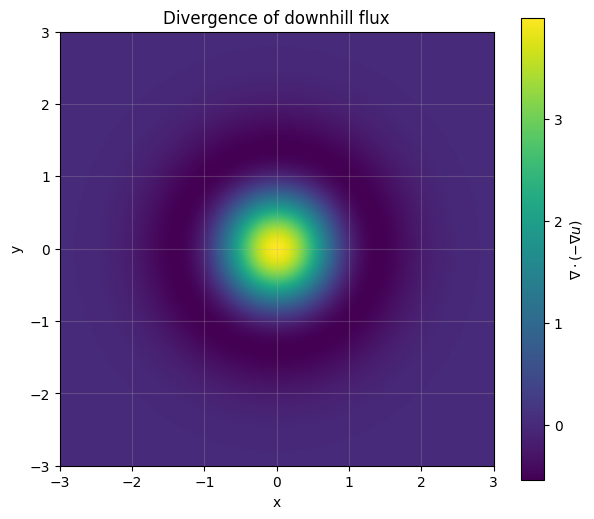

Max |div(-grad u) + Laplacian u|: 0.0


In [13]:
P = -Ux
Q = -Uy
DivFlux = finite_divergence_grid(P, Q, dx, dy)

plt.figure(figsize=(7, 6))
im = plt.imshow(DivFlux, extent=[-3,3,-3,3], origin="lower", aspect="equal")
plt.colorbar(im, label=r"$\nabla\cdot(-\nabla u)$")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Divergence of downhill flux")
plt.grid(True, alpha=0.25)
plt.show()

print("Max |div(-grad u) + Laplacian u|:", np.max(np.abs(DivFlux + LapU)))

---

# Part VI. The heat equation

The heat equation is

$$
u_t=\alpha\Delta u.
$$

It models diffusion of heat, concentration, probability, and information.

With insulated boundaries, total mass is approximately conserved:

$$
\frac{d}{dt}\iint u(x,y,t)\,dA=0.
$$

## 13. Heat diffusion from two hot spots

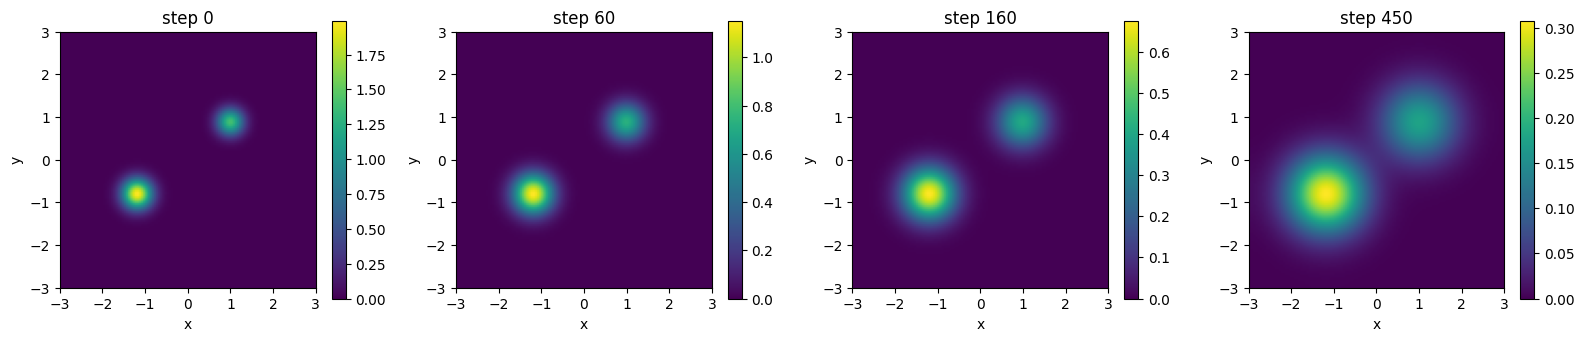

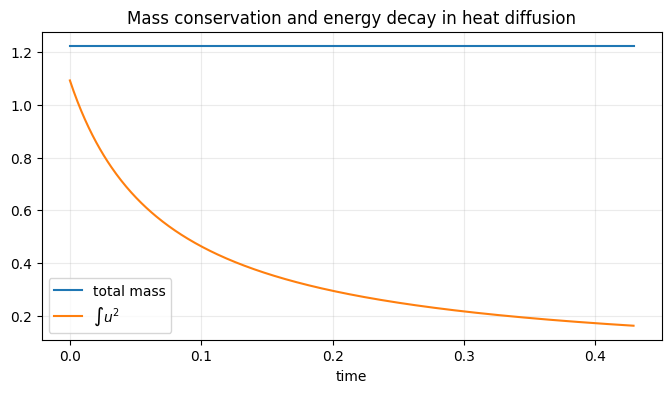

Initial mass: 1.225221134899908
Final mass: 1.225221134899908
Relative mass change: 0.0
Initial integral u^2: 1.0932742434492413
Final integral u^2: 0.16124710457158048


In [14]:
nx = ny = 120
xmin, xmax, ymin, ymax = -3, 3, -3, 3
x = np.linspace(xmin, xmax, nx)
y = np.linspace(ymin, ymax, ny)
X, Y = np.meshgrid(x, y)
dx = x[1] - x[0]
dy = y[1] - y[0]

U0 = (
    2.0*np.exp(-8*((X+1.2)**2 + (Y+0.8)**2))
    + 1.4*np.exp(-10*((X-1.0)**2 + (Y-0.9)**2))
)

alpha = 0.4
dt = 0.15*min(dx, dy)**2/alpha
steps = 450
snapshots = {}
Uheat = U0.copy()
mass_history = []
energy_history = []

for k in range(steps+1):
    if k in [0, 60, 160, 450]:
        snapshots[k] = Uheat.copy()
    mass_history.append(integrate_grid(Uheat, dx, dy))
    energy_history.append(integrate_grid(Uheat**2, dx, dy))
    if k < steps:
        Uheat = heat_step_neumann(Uheat, alpha, dx, dy, dt)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (k, Usnap) in zip(axes, snapshots.items()):
    im = ax.imshow(Usnap, extent=[xmin,xmax,ymin,ymax], origin="lower", aspect="equal")
    ax.set_title(f"step {k}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax, shrink=0.75)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(mass_history))*dt, mass_history, label="total mass")
plt.plot(np.arange(len(energy_history))*dt, energy_history, label=r"$\int u^2$")
plt.xlabel("time")
plt.title("Mass conservation and energy decay in heat diffusion")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print("Initial mass:", mass_history[0])
print("Final mass:", mass_history[-1])
print("Relative mass change:", (mass_history[-1]-mass_history[0])/mass_history[0])
print("Initial integral u^2:", energy_history[0])
print("Final integral u^2:", energy_history[-1])

### Key observation

Diffusion smooths the field.  
Total mass is nearly conserved with insulated boundaries, while the squared energy $\int u^2$ decreases.

---

# Part VII. Poisson equation and steady states

The Poisson equation has the form

$$
-\Delta u=f.
$$

It appears in electrostatics, gravity, pressure equations, steady heat flow, elasticity, and image processing.

We solve a simple Dirichlet problem on a square:

$$
-\Delta u=f,\qquad u=0\text{ on the boundary}.
$$

A Jacobi iteration updates each interior point by averaging neighbors plus source contribution.

## 14. Solve a Poisson equation by Jacobi iteration

dx, dy: 0.022471910112359605 0.022471910112359605


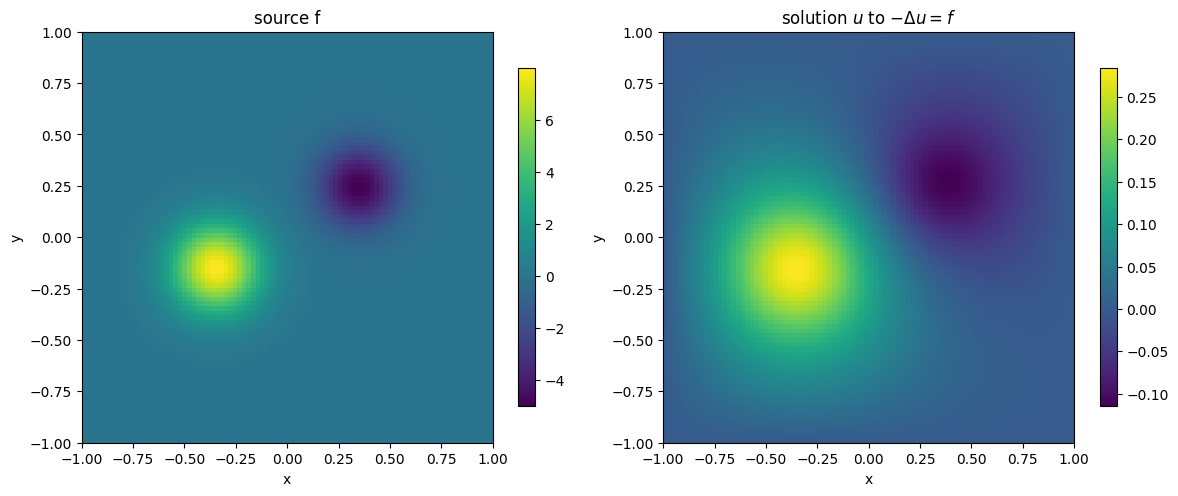

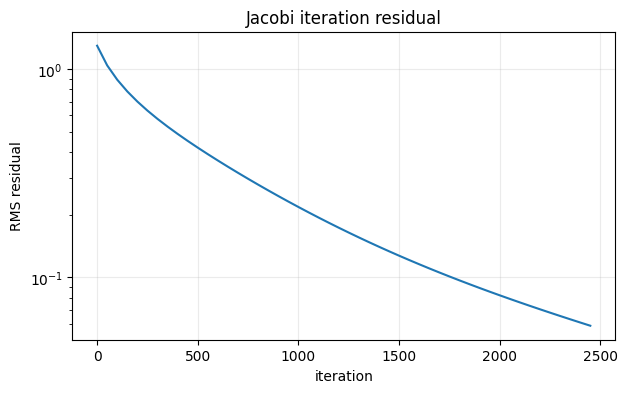

Final RMS residual: 0.05855414834635922


In [15]:
nx = ny = 90
x = np.linspace(-1, 1, nx)
y = np.linspace(-1, 1, ny)
X, Y = np.meshgrid(x, y)
dx = x[1] - x[0]
dy = y[1] - y[0]

# Use equal grid spacing for the simple Jacobi formula.
print("dx, dy:", dx, dy)

f_source = 8*np.exp(-20*((X+0.35)**2 + (Y+0.15)**2)) - 5*np.exp(-25*((X-0.35)**2 + (Y-0.25)**2))

u = np.zeros_like(X)
residual_history = []

h2 = dx**2
for it in range(2500):
    u_new = u.copy()
    u_new[1:-1,1:-1] = 0.25*(
        u[1:-1,2:] + u[1:-1,:-2] + u[2:,1:-1] + u[:-2,1:-1]
        + h2*f_source[1:-1,1:-1]
    )
    if it % 50 == 0:
        lap = (
            (u[1:-1,2:] - 2*u[1:-1,1:-1] + u[1:-1,:-2])/h2
            + (u[2:,1:-1] - 2*u[1:-1,1:-1] + u[:-2,1:-1])/h2
        )
        residual = -lap - f_source[1:-1,1:-1]
        residual_history.append(np.sqrt(np.mean(residual**2)))
    u = u_new

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(f_source, extent=[-1,1,-1,1], origin="lower", aspect="equal")
axes[0].set_title("source f")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0], shrink=0.75)

im1 = axes[1].imshow(u, extent=[-1,1,-1,1], origin="lower", aspect="equal")
axes[1].set_title(r"solution $u$ to $-\Delta u=f$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(im1, ax=axes[1], shrink=0.75)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.semilogy(np.arange(len(residual_history))*50, residual_history)
plt.xlabel("iteration")
plt.ylabel("RMS residual")
plt.title("Jacobi iteration residual")
plt.grid(True, alpha=0.25)
plt.show()

print("Final RMS residual:", residual_history[-1])

---

# Part VIII. Variational energy minimization

Many applied equations arise by minimizing an energy functional.

For the Poisson problem

$$
-\Delta u=f,\qquad u=0\text{ on the boundary},
$$

the energy is

$$
E[u]=\iint \left(\frac12|\nabla u|^2-fu\right)\,dA.
$$

The minimizer satisfies the Poisson equation.

## 15. Compute the energy during a heat-like relaxation

Gradient descent on the energy leads to an evolution similar to

$$
u_t=\Delta u+f.
$$

At steady state, $\Delta u+f=0$.

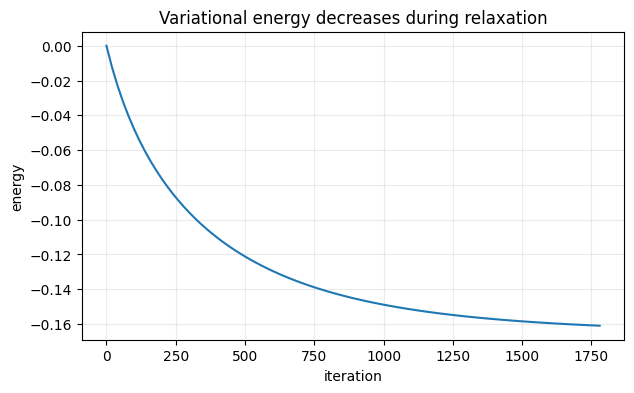

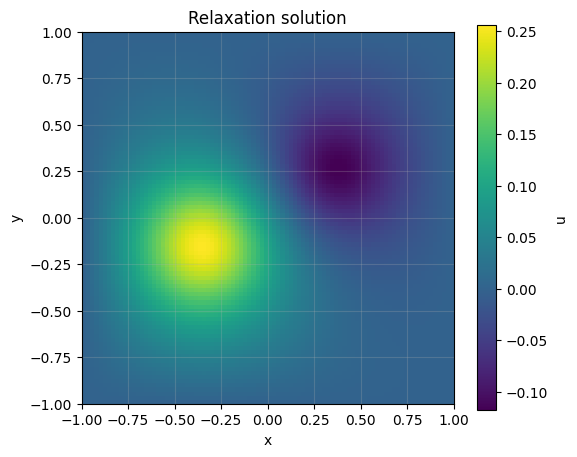

Initial energy: 0.0
Final energy: -0.16095609491432067


In [16]:
def dirichlet_energy(U, Fsrc, dx, dy):
    Ux, Uy = finite_gradient_scalar_grid(U, dx, dy)
    density = 0.5*(Ux**2 + Uy**2) - Fsrc*U
    return integrate_grid(density, dx, dy)

Urelax = np.zeros_like(X)
dt_relax = 0.20*dx**2
energies = []

for k in range(1800):
    if k % 20 == 0:
        energies.append(dirichlet_energy(Urelax, f_source, dx, dy))
    lap = np.zeros_like(Urelax)
    lap[1:-1,1:-1] = (
        (Urelax[1:-1,2:] - 2*Urelax[1:-1,1:-1] + Urelax[1:-1,:-2])/dx**2
        + (Urelax[2:,1:-1] - 2*Urelax[1:-1,1:-1] + Urelax[:-2,1:-1])/dy**2
    )
    Urelax[1:-1,1:-1] += dt_relax*(lap[1:-1,1:-1] + f_source[1:-1,1:-1])
    Urelax[0,:] = 0; Urelax[-1,:] = 0; Urelax[:,0] = 0; Urelax[:,-1] = 0

plt.figure(figsize=(7, 4))
plt.plot(np.arange(len(energies))*20, energies)
plt.xlabel("iteration")
plt.ylabel("energy")
plt.title("Variational energy decreases during relaxation")
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(6, 5))
im = plt.imshow(Urelax, extent=[-1,1,-1,1], origin="lower", aspect="equal")
plt.colorbar(im, label="u")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Relaxation solution")
plt.grid(True, alpha=0.25)
plt.show()

print("Initial energy:", energies[0])
print("Final energy:", energies[-1])

---

# Part IX. Advection-diffusion transport

A common conservation model is

$$
u_t+\mathbf v\cdot\nabla u=D\Delta u+S.
$$

Here:

- $u(x,y,t)$ is concentration;
- $\mathbf v$ is wind or fluid velocity;
- $D$ is diffusion strength;
- $S$ is a source term.

This equation combines directional transport and smoothing.

## 16. Pollutant plume with wind

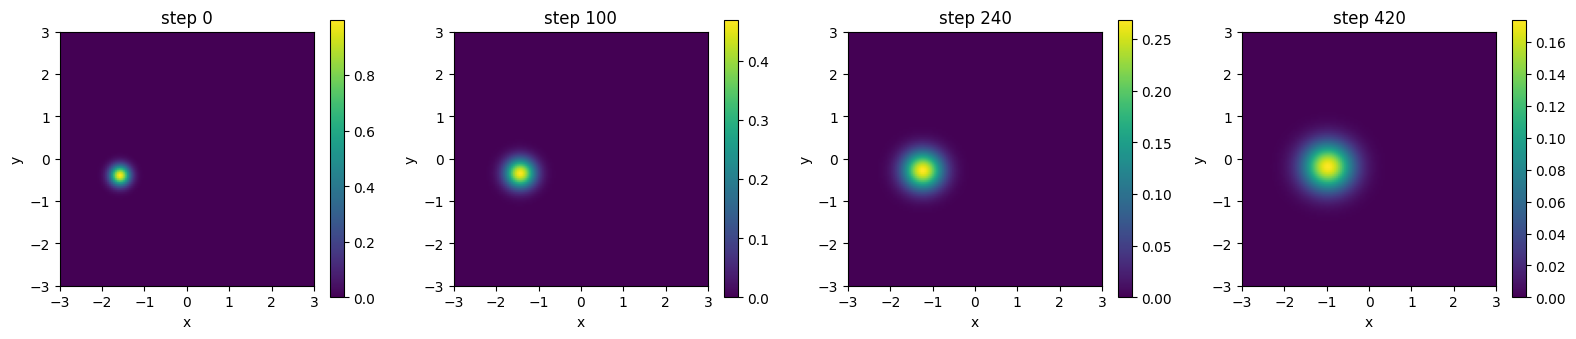

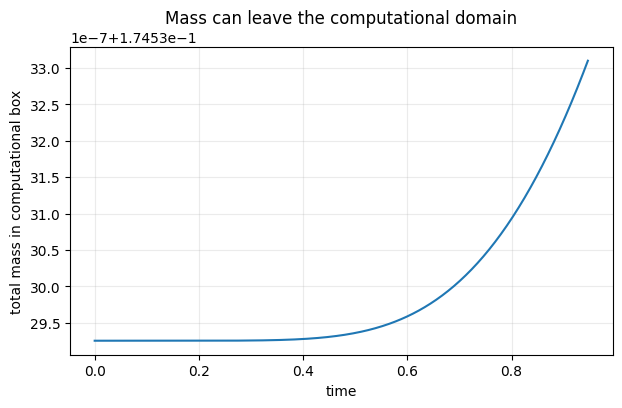

dt used: 0.0022534703443302766
Initial mass: 0.17453292519943356
Final mass: 0.1745333099749101


In [17]:
nx = ny = 130
xmin, xmax, ymin, ymax = -3, 3, -3, 3
x = np.linspace(xmin, xmax, nx)
y = np.linspace(ymin, ymax, ny)
X, Y = np.meshgrid(x, y)
dx = x[1] - x[0]
dy = y[1] - y[0]

Uplume = np.exp(-18*((X+1.6)**2 + (Y+0.4)**2))
D = 0.06
vx, vy = 0.65, 0.22
dt_adv = 0.25*min(dx/max(abs(vx), 1e-12), dy/max(abs(vy), 1e-12), dx**2/(4*D))
steps = 420

snapshots = {}
mass_plume = []

for k in range(steps+1):
    if k in [0, 100, 240, 420]:
        snapshots[k] = Uplume.copy()
    mass_plume.append(integrate_grid(Uplume, dx, dy))
    if k < steps:
        Uplume = upwind_advection_diffusion_step(Uplume, vx, vy, D, dx, dy, dt_adv)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (k, Usnap) in zip(axes, snapshots.items()):
    im = ax.imshow(Usnap, extent=[xmin,xmax,ymin,ymax], origin="lower", aspect="equal")
    ax.set_title(f"step {k}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax, shrink=0.75)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(np.arange(len(mass_plume))*dt_adv, mass_plume)
plt.xlabel("time")
plt.ylabel("total mass in computational box")
plt.title("Mass can leave the computational domain")
plt.grid(True, alpha=0.25)
plt.show()

print("dt used:", dt_adv)
print("Initial mass:", mass_plume[0])
print("Final mass:", mass_plume[-1])

### Interpretation

The plume moves with the wind and spreads by diffusion.  
Mass decreases in the plotted box when material is transported out of the computational domain.

---

# Part X. Flux balance on a control volume

A conservation law often says:

$$
\frac{d}{dt}\int_\Omega u\,dA
=
-\int_{\partial\Omega}\mathbf J\cdot\mathbf n\,ds
+
\int_\Omega S\,dA.
$$

For diffusion,

$$
\mathbf J=-D\nabla u.
$$

Divergence connects boundary flux to interior change:

$$
-\nabla\cdot\mathbf J=D\Delta u.
$$

## 17. Diffusive flux from a concentration field

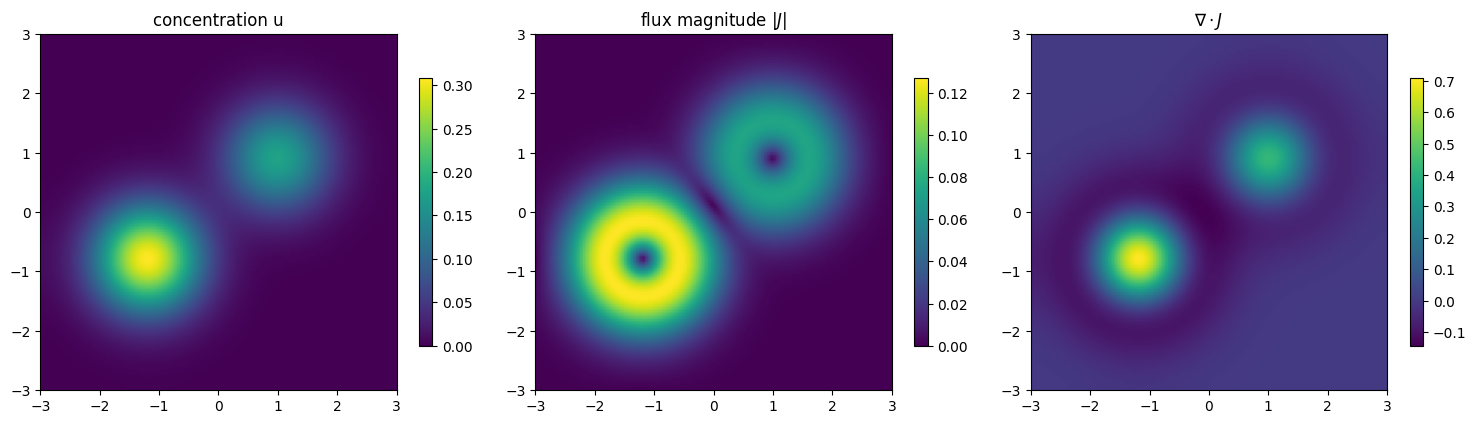

Integral of div(J) over box: -0.00012512042271684774


In [18]:
# Use the final heat field from Part VI.
U_field = Uheat.copy()
Ux, Uy = finite_gradient_scalar_grid(U_field, dx, dy)
Jx = -alpha*Ux
Jy = -alpha*Uy
DivJ = finite_divergence_grid(Jx, Jy, dx, dy)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].imshow(U_field, extent=[xmin,xmax,ymin,ymax], origin="lower", aspect="equal")
axes[0].set_title("concentration u")
fig.colorbar(im0, ax=axes[0], shrink=0.75)

im1 = axes[1].imshow(np.sqrt(Jx**2+Jy**2), extent=[xmin,xmax,ymin,ymax], origin="lower", aspect="equal")
axes[1].set_title(r"flux magnitude $|J|$")
fig.colorbar(im1, ax=axes[1], shrink=0.75)

im2 = axes[2].imshow(DivJ, extent=[xmin,xmax,ymin,ymax], origin="lower", aspect="equal")
axes[2].set_title(r"$\nabla\cdot J$")
fig.colorbar(im2, ax=axes[2], shrink=0.75)

plt.tight_layout()
plt.show()

print("Integral of div(J) over box:", integrate_grid(DivJ, dx, dy))

---

# Part XI. Nondimensionalization and scaling

Applied models often contain parameters.  
Scaling variables can reveal the important dimensionless groups.

For the diffusion equation

$$
u_t=D u_{xx},
$$

choose a length scale $L$ and time scale $T=L^2/D$.  
Then

$$
\tau=\frac{t}{T},\qquad \xi=\frac{x}{L}
$$

turns the equation into

$$
u_\tau=u_{\xi\xi}.
$$

This reduces the number of parameters.

## 18. Diffusion time scale

       D L= 0.5 L= 1.0 L= 2.0 L= 5.0
   0.010    25.00   100.00   400.00  2500.00
   0.050     5.00    20.00    80.00   500.00
   0.100     2.50    10.00    40.00   250.00
   0.500     0.50     2.00     8.00    50.00
   1.000     0.25     1.00     4.00    25.00


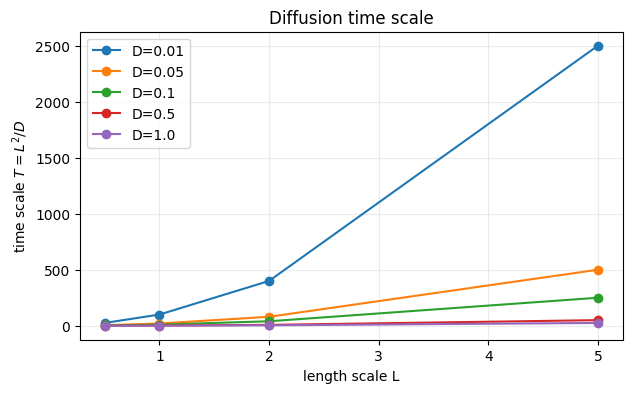

In [19]:
D_values = np.array([0.01, 0.05, 0.1, 0.5, 1.0])
L_values = np.array([0.5, 1.0, 2.0, 5.0])

print(f"{'D':>8s} " + " ".join([f"L={L:>4.1f}" for L in L_values]))
for Dval in D_values:
    times = L_values**2/Dval
    print(f"{Dval:8.3f} " + " ".join([f"{T:8.2f}" for T in times]))

plt.figure(figsize=(7, 4))
for Dval in D_values:
    plt.plot(L_values, L_values**2/Dval, marker="o", label=f"D={Dval}")
plt.xlabel("length scale L")
plt.ylabel(r"time scale $T=L^2/D$")
plt.title("Diffusion time scale")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---

# Part XII. Chapter mini-project: wind, diffusion, and a source

In this mini-project, we model pollutant concentration $u(x,y,t)$ on a square domain.

The model is

$$
u_t+\mathbf v\cdot\nabla u
=
D\Delta u+S(x,y)-\lambda u.
$$

Here:

- $\mathbf v$ is wind velocity;
- $D$ is diffusion;
- $S$ is a localized source;
- $\lambda u$ is decay or removal.

You will compute the evolving plume, total mass, peak concentration, and center of mass.

## 19. Define and simulate the model

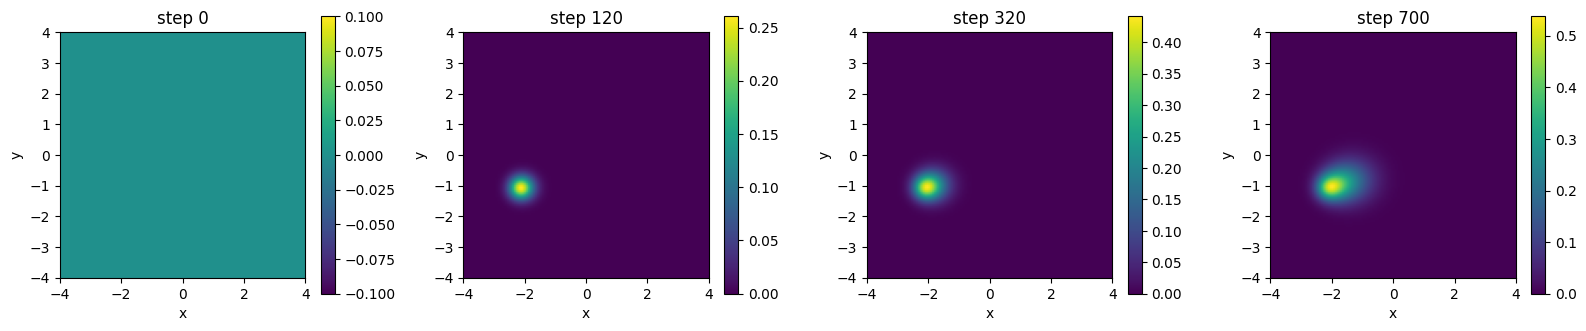

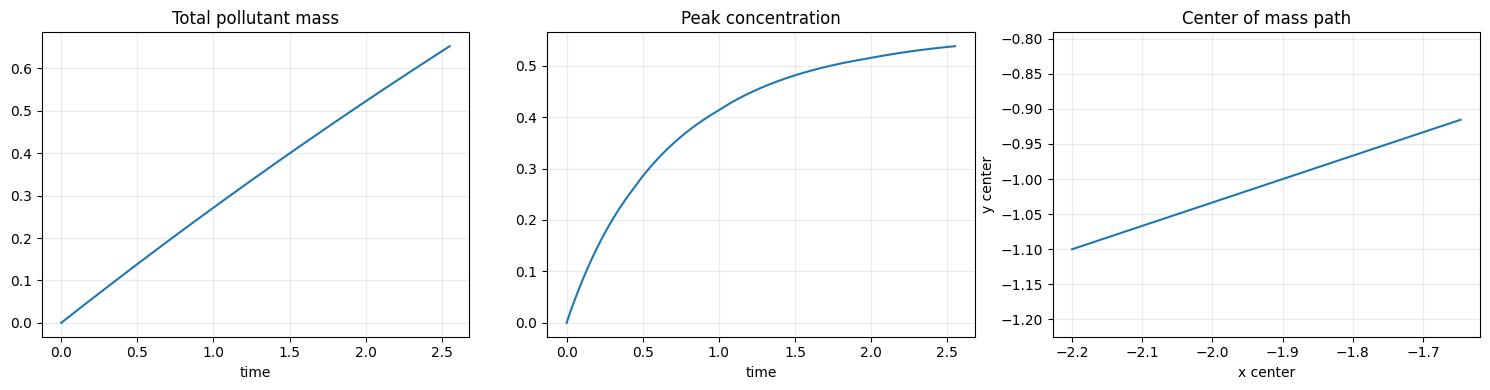

dt: 0.0036437037420423476
Final mass: 0.6522428394917893
Final peak concentration: 0.5378201215045879
Final center of mass: (-1.646445011511095, -0.9154806033133993)


In [20]:
nx = ny = 140
xmin, xmax, ymin, ymax = -4, 4, -4, 4
x = np.linspace(xmin, xmax, nx)
y = np.linspace(ymin, ymax, ny)
X, Y = np.meshgrid(x, y)
dx = x[1] - x[0]
dy = y[1] - y[0]

D = 0.05
vx, vy = 0.45, 0.15
lam = 0.08

source = 0.9*np.exp(-10*((X+2.2)**2 + (Y+1.1)**2))
Umodel = np.zeros_like(X)

dt = 0.22*min(dx/max(abs(vx), 1e-12), dy/max(abs(vy), 1e-12), dx**2/(4*D))
steps = 700

snapshots = {}
mass = []
peak = []
center_x = []
center_y = []

for k in range(steps+1):
    if k in [0, 120, 320, 700]:
        snapshots[k] = Umodel.copy()
    m = integrate_grid(Umodel, dx, dy)
    mass.append(m)
    peak.append(float(np.max(Umodel)))
    if m > 1e-12:
        center_x.append(integrate_grid(X*Umodel, dx, dy)/m)
        center_y.append(integrate_grid(Y*Umodel, dx, dy)/m)
    else:
        center_x.append(np.nan)
        center_y.append(np.nan)
    if k < steps:
        Umodel = upwind_advection_diffusion_step(Umodel, vx, vy, D, dx, dy, dt, source=source)
        Umodel = Umodel - dt*lam*Umodel
        Umodel = np.maximum(Umodel, 0)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (k, Usnap) in zip(axes, snapshots.items()):
    im = ax.imshow(Usnap, extent=[xmin,xmax,ymin,ymax], origin="lower", aspect="equal")
    ax.set_title(f"step {k}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax, shrink=0.75)
plt.tight_layout()
plt.show()

time = np.arange(steps+1)*dt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(time, mass)
axes[0].set_title("Total pollutant mass")
axes[0].set_xlabel("time")
axes[0].grid(True, alpha=0.25)

axes[1].plot(time, peak)
axes[1].set_title("Peak concentration")
axes[1].set_xlabel("time")
axes[1].grid(True, alpha=0.25)

axes[2].plot(center_x, center_y)
axes[2].set_title("Center of mass path")
axes[2].set_xlabel("x center")
axes[2].set_ylabel("y center")
axes[2].axis("equal")
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print("dt:", dt)
print("Final mass:", mass[-1])
print("Final peak concentration:", peak[-1])
print("Final center of mass:", (center_x[-1], center_y[-1]))

## 20. Mini-project questions

Answer the following in a markdown cell:

1. What is the role of the advection term $\mathbf v\cdot\nabla u$?
2. What is the role of the diffusion term $D\Delta u$?
3. What is the role of the decay term $-\lambda u$?
4. Why does the center of mass move in the wind direction?
5. Does total mass reach a steady state? Why?
6. How would the plume change if $D$ were larger?
7. How would the plume change if $\lambda$ were zero?

In [21]:
print("Mini-project summary")
print("--------------------")
print("Wind velocity:", (vx, vy))
print("Diffusion D:", D)
print("Decay lambda:", lam)
print("Initial mass:", mass[0])
print("Final mass:", mass[-1])
print("Maximum mass over time:", np.max(mass))
print("Final peak concentration:", peak[-1])
print("Final center of mass:", (center_x[-1], center_y[-1]))

Mini-project summary
--------------------
Wind velocity: (0.45, 0.15)
Diffusion D: 0.05
Decay lambda: 0.08
Initial mass: 0.0
Final mass: 0.6522428394917893
Maximum mass over time: 0.6522428394917893
Final peak concentration: 0.5378201215045879
Final center of mass: (-1.646445011511095, -0.9154806033133993)


---

# Part XIII. Additional exercises with reference solutions

Try each exercise before running the reference solution.

## Exercise A. Linear system classification

For

$$
A=\begin{bmatrix}2&1\\1&2\end{bmatrix},
$$

compute the eigenvalues and classify the equilibrium at the origin for $\mathbf x'=A\mathbf x$.

In [22]:
# Exercise A workspace

# Your code here

### Reference solution for Exercise A

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Eigenvalues: [3. 1.]
Both eigenvalues are positive, so the origin is an unstable source.


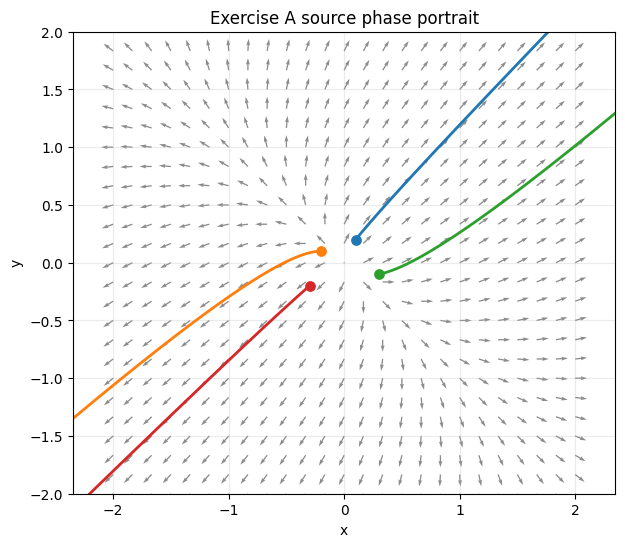

In [23]:
A_ex = np.array([[2,1],[1,2]], dtype=float)
eig_ex = np.linalg.eigvals(A_ex)

print("Eigenvalues:", eig_ex)
print("Both eigenvalues are positive, so the origin is an unstable source.")

plot_phase_paths(
    lambda z: A_ex @ z,
    [[0.1,0.2], [-0.2,0.1], [0.3,-0.1], [-0.3,-0.2]],
    xmin=-2, xmax=2,
    ymin=-2, ymax=2,
    t1=2.2,
    dt=0.01,
    title="Exercise A source phase portrait"
)

## Exercise B. Energy decay

For

$$
V(x,y)=\frac12(x^2+4y^2),
$$

simulate the gradient flow from $(2,1)$ and plot $V(t)$.

In [24]:
# Exercise B workspace

# Your code here

### Reference solution for Exercise B

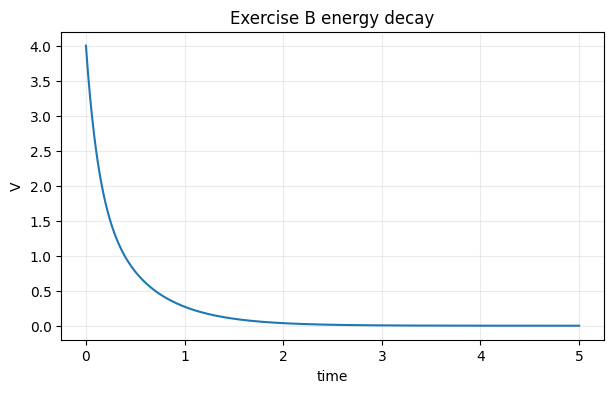

Initial energy: 4.0
Final energy: 9.079986075599455e-05


In [25]:
def V_B(X, Y):
    return 0.5*(X**2 + 4*Y**2)

def F_B_state(z):
    x, y = z
    return np.array([-x, -4*y])

tB, XB = rk4_solve(lambda t, z: F_B_state(z), np.array([2.0, 1.0]), 0, 5, 0.02)
VB = V_B(XB[:,0], XB[:,1])

plt.figure(figsize=(7, 4))
plt.plot(tB, VB)
plt.xlabel("time")
plt.ylabel("V")
plt.title("Exercise B energy decay")
plt.grid(True, alpha=0.25)
plt.show()

print("Initial energy:", VB[0])
print("Final energy:", VB[-1])

## Exercise C. Numerical Laplacian

For

$$
u(x,y)=\sin x\cos y,
$$

verify numerically that

$$
\Delta u=-2\sin x\cos y.
$$

In [26]:
# Exercise C workspace

# Your code here

### Reference solution for Exercise C

In [27]:
x, y, X, Y = make_grid(-np.pi, np.pi, -np.pi, np.pi, n=240)
dx = x[1]-x[0]
dy = y[1]-y[0]
U = np.sin(X)*np.cos(Y)
Lap_num = finite_laplacian_grid(U, dx, dy)
Lap_exact = -2*np.sin(X)*np.cos(Y)

# Ignore a few boundary points where finite-difference edge errors are larger.
err = np.max(np.abs(Lap_num[4:-4,4:-4] - Lap_exact[4:-4,4:-4]))

print("Maximum interior error:", err)

Maximum interior error: 0.00046066556996438024


## Exercise D. Heat equation mass

Run heat diffusion with insulated boundaries for a single hot spot. Check that total mass is approximately conserved.

In [28]:
# Exercise D workspace

# Your code here

### Reference solution for Exercise D

In [29]:
nx = ny = 90
x = np.linspace(-2, 2, nx)
y = np.linspace(-2, 2, ny)
X, Y = np.meshgrid(x, y)
dx = x[1]-x[0]
dy = y[1]-y[0]
U_D = np.exp(-10*(X**2+Y**2))
alpha_D = 0.3
dt_D = 0.18*min(dx,dy)**2/alpha_D

mass_D = []
for k in range(250):
    mass_D.append(integrate_grid(U_D, dx, dy))
    U_D = heat_step_neumann(U_D, alpha_D, dx, dy, dt_D)

print("Initial mass:", mass_D[0])
print("Final mass:", mass_D[-1])
print("Relative change:", (mass_D[-1]-mass_D[0])/mass_D[0])

Initial mass: 0.31415926535898087
Final mass: 0.31415926535898087
Relative change: 0.0


## Exercise E. Jacobian linearization

For

$$
\mathbf F(x,y)=\langle x-y^2,\;xy-1\rangle,
$$

find the numerical Jacobian at $(1,1)$.

In [30]:
# Exercise E workspace

# Your code here

### Reference solution for Exercise E

In [31]:
def F_E_state(z):
    x, y = z
    return np.array([x-y**2, x*y-1])

J_E = finite_jacobian(F_E_state, np.array([1.0, 1.0]))
J_exact_E = np.array([[1, -2], [1, 1]], dtype=float)

print("Numerical Jacobian:")
print(J_E)
print("Exact Jacobian:")
print(J_exact_E)
print("Difference:")
print(J_E - J_exact_E)

Numerical Jacobian:
[[ 1. -2.]
 [ 1.  1.]]
Exact Jacobian:
[[ 1. -2.]
 [ 1.  1.]]
Difference:
[[ 0. -0.]
 [ 0.  0.]]


---

# Formula summary

## Linear dynamical system

$$
\mathbf x'=A\mathbf x.
$$

## Nonlinear linearization

Near an equilibrium $\mathbf x_*$,

$$
\mathbf h'=J_{\mathbf F}(\mathbf x_*)\mathbf h.
$$

## Gradient flow

$$
\mathbf x'=-\nabla V(\mathbf x).
$$

Energy decreases:

$$
\frac{d}{dt}V(\mathbf x(t))=-|\nabla V(\mathbf x(t))|^2.
$$

## Hamiltonian system

$$
x'=H_y,\qquad y'=-H_x.
$$

Energy is conserved:

$$
\frac{dH}{dt}=0.
$$

## Gradient, divergence, and Laplacian

$$
\nabla u=\langle u_x,u_y\rangle,
$$

$$
\nabla\cdot\mathbf F=P_x+Q_y,
$$

$$
\Delta u=u_{xx}+u_{yy}.
$$

## Heat equation

$$
u_t=\alpha\Delta u.
$$

## Poisson equation

$$
-\Delta u=f.
$$

## Advection-diffusion-reaction equation

$$
u_t+\mathbf v\cdot\nabla u
=
D\Delta u+S-\lambda u.
$$

## Diffusive flux

$$
\mathbf J=-D\nabla u.
$$

## Conservation balance

$$
\frac{d}{dt}\int_\Omega u\,dA
=
-\int_{\partial\Omega}\mathbf J\cdot\mathbf n\,ds+\int_\Omega S\,dA.
$$

## Diffusion time scale

$$
T=\frac{L^2}{D}.
$$

# End of Chapter 26 Lab

You have used Python to explore:

- linear and nonlinear dynamical systems,
- eigenvalues and phase portraits,
- Jacobian linearization,
- predator-prey dynamics,
- gradient flows and energy decay,
- Hamiltonian systems and energy conservation,
- numerical gradients, divergence, and Laplacians,
- heat diffusion,
- Poisson equations and steady states,
- variational energy minimization,
- advection-diffusion transport,
- flux and conservation,
- scaling and nondimensionalization,
- and a wind-driven pollutant mini-project.

This chapter shows how multivariable calculus becomes a modeling language for applied mathematics, scientific computing, physics, biology, engineering, and data-driven systems.